In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    df = pd.read_csv(url)
    print("Titanic dataset loaded online.")
except Exception as e:
    print("Online loading failed:", e)
    print("Please upload your Titanic CSV file.")

    from google.colab import files
    uploaded = files.upload()

    csv_file = next(
        name for name in uploaded
        if name.lower().endswith(".csv")
    )

    df = pd.read_csv(csv_file)

print("Dataset shape:", df.shape)
display(df.head())

Titanic dataset loaded online.
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# 1. Dataset dimensions
print("Dataset shape:", df.shape)

# 2. First five rows
display(df.head())

# 3. Column names and data types
print("\nDataset information:")
df.info()

# 4. Statistical summary
print("\nStatistical summary:")
display(df.describe())

# 5. Summary including categorical columns
display(df.describe(include="all"))

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistical summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
# Missing values count
missing_count = df.isnull().sum()

# Missing values percentage
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage", ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [8]:
# Work on a copy, keeping the original dataset unchanged
eda_df = df.copy()

# Drop Cabin because it has a very high proportion of missing values
if "Cabin" in eda_df.columns:
    cabin_missing = eda_df["Cabin"].isnull().mean() * 100
    print(f"Cabin missing: {cabin_missing:.2f}%")

    if cabin_missing > 40:
        eda_df.drop(columns=["Cabin"], inplace=True)
        print("Cabin column dropped.")

# Fill remaining missing values
for col in eda_df.columns:
    if eda_df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(eda_df[col]):
            median_value = eda_df[col].median()
            eda_df[col] = eda_df[col].fillna(median_value)
            print(f"{col}: filled with median ({median_value})")
        else:
            mode_values = eda_df[col].mode()
            if not mode_values.empty:
                mode_value = mode_values.iloc[0]
                eda_df[col] = eda_df[col].fillna(mode_value)
                print(f"{col}: filled with mode ({mode_value})")

print("\nMissing values remaining:")
print(eda_df.isnull().sum().sum())

Cabin missing: 77.10%
Cabin column dropped.
Age: filled with median (28.0)
Embarked: filled with mode (S)

Missing values remaining:
0


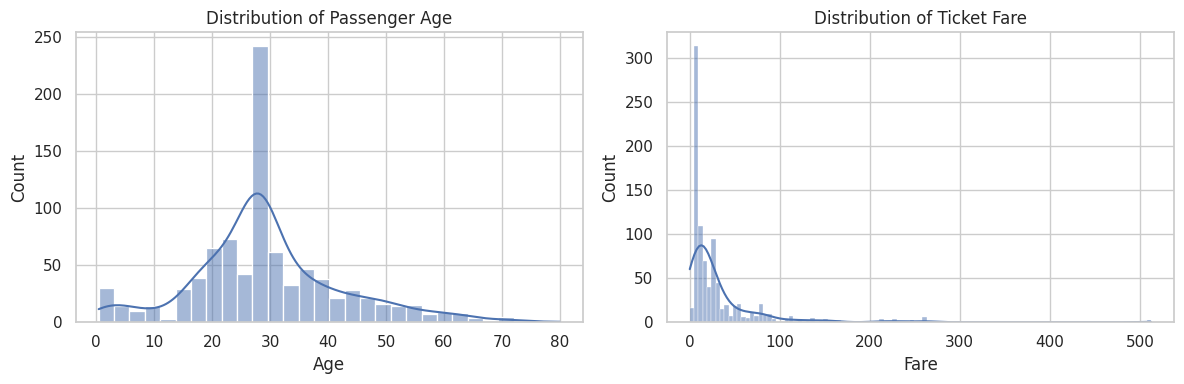

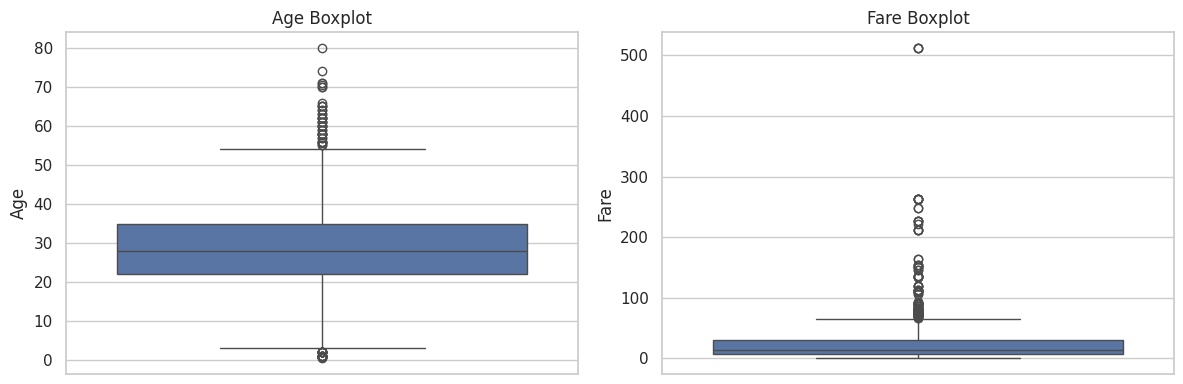

In [9]:
# Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda_df["Age"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Passenger Age")
axes[0].set_xlabel("Age")

sns.histplot(eda_df["Fare"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Ticket Fare")
axes[1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=eda_df["Age"], ax=axes[0])
axes[0].set_title("Age Boxplot")

sns.boxplot(y=eda_df["Fare"], ax=axes[1])
axes[1].set_title("Fare Boxplot")

plt.tight_layout()
plt.show()

In [10]:
def iqr_analysis(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f"\n{column} IQR Analysis")
    print("Q1:", round(Q1, 2))
    print("Q3:", round(Q3, 2))
    print("IQR:", round(IQR, 2))
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Outlier count:", len(outliers))

    return outliers

age_outliers = iqr_analysis(eda_df, "Age")
fare_outliers = iqr_analysis(eda_df, "Fare")


Age IQR Analysis
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Outlier count: 66

Fare IQR Analysis
Q1: 7.91
Q3: 31.0
IQR: 23.09
Lower bound: -26.72
Upper bound: 65.63
Outlier count: 116


,Sex,Survival Rate (%)
0,female,74.20
1,male,18.89


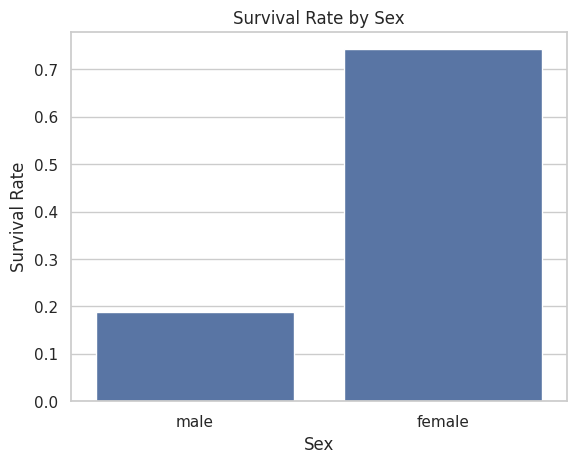

In [11]:
# Survival rate by sex
survival_by_sex = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="Survival Rate (%)")
)

display(survival_by_sex)

sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    errorbar=None
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

Did Not Survive (%)  Survived (%)
Sex    Pclass                                   
female 1                      3.19         96.81
       2                      7.89         92.11
       3                     50.00         50.00
male   1                     63.11         36.89
       2                     84.26         15.74
       3                     86.46         13.54

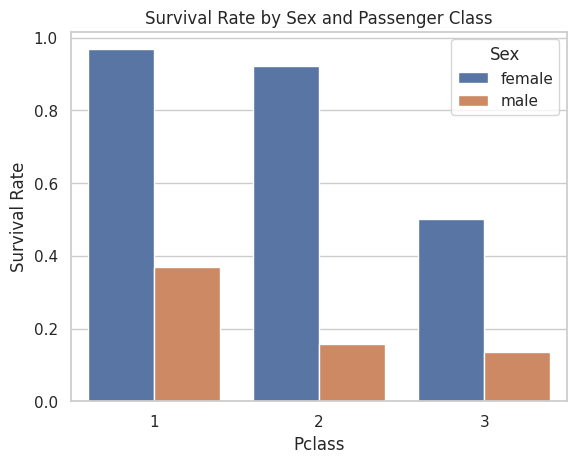

In [12]:
survival_sex_class = pd.crosstab(
    [df["Sex"], df["Pclass"]],
    df["Survived"],
    normalize="index"
) * 100

survival_sex_class.columns = [
    "Did Not Survive (%)",
    "Survived (%)"
]

display(survival_sex_class.round(2))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

6 x 6 Correlation Matrix:


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.00,-0.34,-0.08,-0.04,0.08,0.26
Pclass,-0.34,1.00,-0.37,0.08,0.02,-0.55
Age,-0.08,-0.37,1.00,-0.31,-0.19,0.10
SibSp,-0.04,0.08,-0.31,1.00,0.41,0.16
Parch,0.08,0.02,-0.19,0.41,1.00,0.22
Fare,0.26,-0.55,0.10,0.16,0.22,1.00


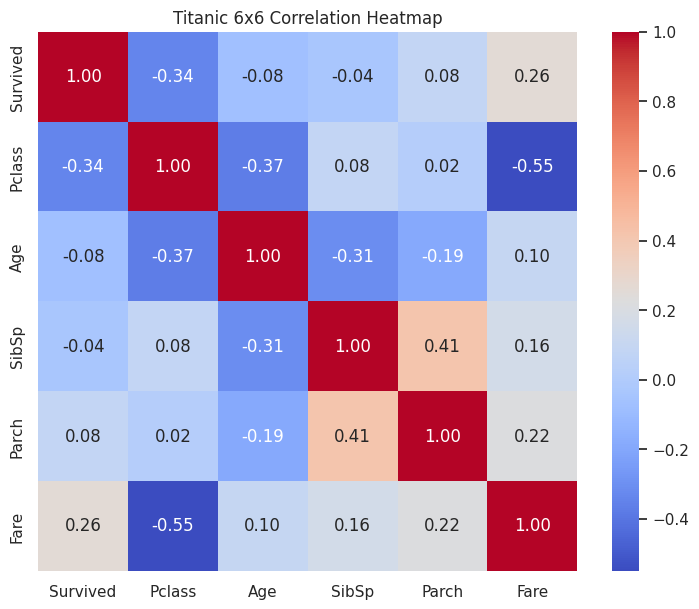

In [13]:
numeric_cols = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

corr_matrix = df[numeric_cols].corr()

print("6 x 6 Correlation Matrix:")
display(corr_matrix.round(2))

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Titanic 6x6 Correlation Heatmap")
plt.show()

In [14]:
for column in ["Age", "Fare"]:
    print(f"\n{column}")
    print("Mean:", round(df[column].mean(), 2))
    print("Median:", round(df[column].median(), 2))
    print("Mode:", round(df[column].mode().iloc[0], 2))


Age
Mean: 29.7
Median: 28.0
Mode: 24.0

Fare
Mean: 32.2
Median: 14.45
Mode: 8.05


## EDA Interpretations

1. Survival by sex:
   Compare the survival rates for male and female passengers.
   Describe the observed difference using the calculated percentages.

2. Survival by passenger class:
   Compare survival rates across first, second, and third class.
   Describe how survival rates vary by class.

3. Survival by sex and class:
   Identify which sex-class groups have higher and lower
   observed survival rates.

4. Correlation:
   Examine the relationship between survival, passenger class,
   age, and fare. Correlation does not establish causation.

5. Distribution:
   Compare mean, median, and mode for Age and Fare.
   If the mean is higher than the median, this may indicate
   right-skewness, especially when supported by the histograms.

6. Outliers:
   Discuss the IQR outliers for Age and Fare. Extreme fares
   may be valid observations rather than data errors.

In [15]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Remove columns that are identifiers or have too many unique values
X = X.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"],
    errors="ignore"
)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining survival distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting survival distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data: (712, 7)
Testing data: (179, 7)

Training survival distribution:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Testing survival distribution:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Fit only on training data
    pipeline.fit(X_train, y_train)

    # Predict test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, zero_division=0
    )
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    trained_models[name] = pipeline

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred, zero_division=0
    ))

results_df = pd.DataFrame(results)
display(results_df.round(4))


Logistic Regression
Confusion Matrix:
[[98 12]
 [23 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Decision Tree
Confusion Matrix:
[[97 13]
 [20 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179


Random Forest
Confusion Matrix:
[[98 12]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
   

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
1,Decision Tree,0.8156,0.7903,0.7101,0.7481,0.7904
2,Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300


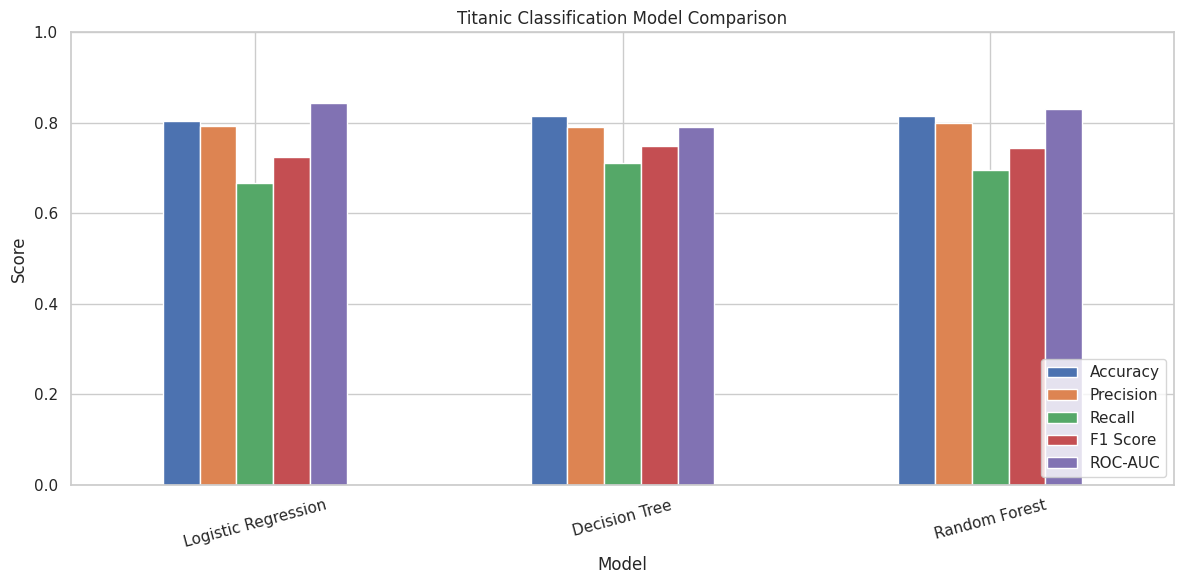

In [18]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Titanic Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [19]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentages:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

Training target distribution:
Survived
0    439
1    273
Name: count, dtype: int64

Training target percentages:
Survived
0    61.66
1    38.34
Name: proportion, dtype: float64


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

balanced_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_lr.fit(X_train, y_train)

balanced_pred = balanced_lr.predict(X_test)
balanced_prob = balanced_lr.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression")
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(
    y_test, balanced_pred, zero_division=0
))
print("Recall:", recall_score(
    y_test, balanced_pred, zero_division=0
))
print("F1:", f1_score(
    y_test, balanced_pred, zero_division=0
))
print("ROC-AUC:", roc_auc_score(y_test, balanced_prob))

Balanced Logistic Regression
Accuracy: 0.8044692737430168
Precision: 0.7297297297297297
Recall: 0.782608695652174
F1: 0.7552447552447552
ROC-AUC: 0.8463768115942027


In [21]:
!pip install imbalanced-learn

In [22]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

smote_pipeline.fit(X_train, y_train)

smote_pred = smote_pipeline.predict(X_test)
smote_prob = smote_pipeline.predict_proba(X_test)[:, 1]

print("SMOTE Logistic Regression")
print("Accuracy:", accuracy_score(y_test, smote_pred))
print("Precision:", precision_score(
    y_test, smote_pred, zero_division=0
))
print("Recall:", recall_score(
    y_test, smote_pred, zero_division=0
))
print("F1:", f1_score(
    y_test, smote_pred, zero_division=0
))
print("ROC-AUC:", roc_auc_score(y_test, smote_prob))

SMOTE Logistic Regression
Accuracy: 0.8100558659217877
Precision: 0.7397260273972602
Recall: 0.782608695652174
F1: 0.7605633802816901
ROC-AUC: 0.8413702239789196


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True,
        bootstrap=True
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best cross-validation F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best cross-validation F1:
0.75366347810578


In [24]:
best_rf = grid_search.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(
    y_test, rf_pred, zero_division=0
))
print("Recall:", recall_score(
    y_test, rf_pred, zero_division=0
))
print("F1:", f1_score(
    y_test, rf_pred, zero_division=0
))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, rf_pred))

# Out-of-bag score from the fitted forest
forest = best_rf.named_steps["classifier"]
print("\nOOB score:", forest.oob_score_)

Tuned Random Forest
Accuracy: 0.8156424581005587
Precision: 0.8333333333333334
Recall: 0.6521739130434783
F1: 0.7317073170731707
ROC-AUC: 0.8308300395256918

Confusion matrix:
[[101   9]
 [ 24  45]]

OOB score: 0.8230337078651685


In [25]:
import joblib

joblib.dump(
    best_rf,
    "best_titanic_pipeline.joblib"
)

print("Best pipeline saved successfully.")

Best pipeline saved successfully.


In [26]:
loaded_model = joblib.load(
    "best_titanic_pipeline.joblib"
)

# Predict using raw test features
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0, 1]

print("Sample passenger:")
display(sample)

print("Predicted survival:", prediction)
print("Survival probability:", round(probability, 4))

Sample passenger:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.15,S


Predicted survival: 0
Survival probability: 0.1174


In [27]:
# Import required libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Use the Titanic DataFrame already loaded in your notebook
reg_df = df.copy()

# Remove rows where Fare is missing
reg_df = reg_df.dropna(subset=["Fare"])

# Features and target
X_reg = reg_df.drop(columns=["Fare", "PassengerId", "Name", "Ticket", "Cabin"],
                    errors="ignore")
y_reg = reg_df["Fare"]

# Separate numerical and categorical columns
num_cols = X_reg.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_reg.select_dtypes(exclude=np.number).columns.tolist()

# Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Split before fitting preprocessing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

# Build and train regression pipeline
reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

reg_model.fit(X_train_reg, y_train_reg)

# Predict test fares
y_pred_reg = reg_model.predict(X_test_reg)

print("Regression model trained successfully!")
print("Training rows:", len(X_train_reg))
print("Testing rows:", len(X_test_reg))

Regression model trained successfully!
Training rows: 712
Testing rows: 179


In [28]:
# Calculate regression metrics

mae = mean_absolute_error(y_test_reg, y_pred_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, y_pred_reg)

# Adjusted R-squared
n = len(y_test_reg)
p = X_train_reg.shape[1]

if n > p + 1:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan

# MASE: compare MAE against a naive training-set baseline
# Baseline predicts the training-set median fare for every test row
naive_prediction = np.full(
    len(y_test_reg),
    y_train_reg.median()
)

naive_mae = mean_absolute_error(
    y_test_reg,
    naive_prediction
)

mase = mae / naive_mae if naive_mae != 0 else np.nan

# Display results
regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MASE",
        "R²",
        "Adjusted R²"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        mase,
        r2,
        adjusted_r2
    ]
})

print(regression_results.to_string(index=False))

     Metric       Value
        MAE   15.276950
        MSE 1721.405456
       RMSE   41.489824
       MASE    0.701402
         R²   -0.112429
Adjusted R²   -0.157967


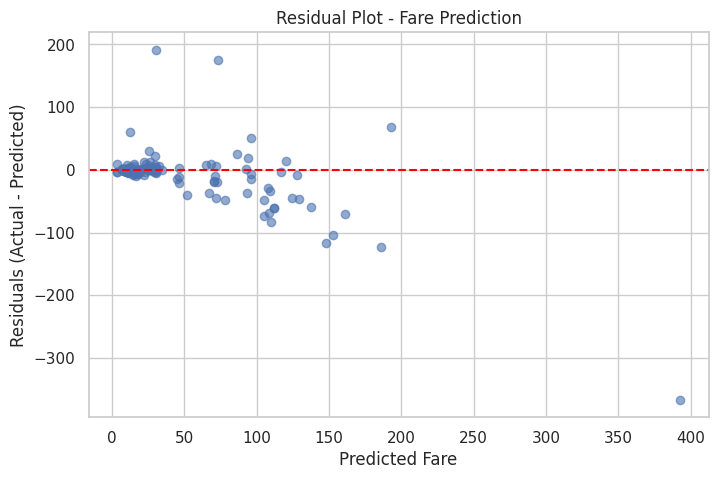

In [29]:
import matplotlib.pyplot as plt

# Residuals = actual fare - predicted fare
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_reg, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Fare Prediction")
plt.grid(True)
 plt.show()

### Residual Plot Interpretation

Residuals are the differences between actual and predicted fares.
A good regression model should have residuals randomly distributed
around zero. Patterns or large residuals indicate prediction errors
and may suggest that the model does not capture all fare-related
relationships in the data.

In [30]:
print("Available classification models:")

for name in [
    "log_model",
    "dt_model",
    "rf_model",
    "best_model",
    "grid_search",
    "X_train",
    "X_test",
    "y_train",
    "y_test"
]:
    if name in globals():
        print(name, "exists")

Available classification models:
grid_search exists
X_train exists
X_test exists
y_train exists
y_test exists


In [31]:
# Find trained classification models and pipelines

from sklearn.pipeline import Pipeline
from sklearn.base import ClassifierMixin

print("Classification models found:\n")

for name, obj in globals().copy().items():
    try:
        if isinstance(obj, ClassifierMixin):
            print(name, "->", type(obj).__name__)

        elif isinstance(obj, Pipeline):
            print(name, "-> Pipeline")
    except Exception:
        pass

Classification models found:

numeric_transformer -> Pipeline
categorical_transformer -> Pipeline
model -> RandomForestClassifier
pipeline -> Pipeline
balanced_lr -> Pipeline
smote_pipeline -> Pipeline
rf_pipeline -> Pipeline
best_rf -> Pipeline
forest -> RandomForestClassifier
loaded_model -> Pipeline
reg_model -> Pipeline


In [33]:
import joblib
import os

# Save the best Random Forest pipeline
joblib.dump(best_rf, "best_titanic_model.joblib")

print("Model saved successfully!")

print("File exists:", os.path.exists("best_titanic_model.joblib"))

Model saved successfully!
File exists: True


In [34]:
# Load the saved model
loaded_model = joblib.load("best_titanic_model.joblib")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [35]:
# Take one passenger from the test dataset
sample_passenger = X_test.iloc[[0]]

# Predict using the reloaded model
prediction = loaded_model.predict(sample_passenger)

print("Passenger details:")
display(sample_passenger)

print("Predicted survival:", int(prediction[0]))

if prediction[0] == 1:
    print("Prediction: Survived")
else:
    print("Prediction: Did not survive")

Passenger details:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.15,S


Predicted survival: 0
Prediction: Did not survive


In [36]:
from google.colab import files

files.download("best_titanic_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np

# Models available in your notebook
models = {
    "Random Forest": best_rf,
    "Balanced Logistic Regression": balanced_lr,
    "SMOTE Pipeline": smote_pipeline
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, zero_division=0
        )
    }

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        row["ROC-AUC"] = roc_auc_score(y_test, y_prob)
    else:
        row["ROC-AUC"] = np.nan

    results.append(row)

final_comparison = pd.DataFrame(results)

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8156,0.8333,0.6522,0.7317,0.8308
1,Balanced Logistic Regression,0.8045,0.7297,0.7826,0.7552,0.8464
2,SMOTE Pipeline,0.8101,0.7397,0.7826,0.7606,0.8414


In [38]:
final_comparison.to_csv(
    "titanic_final_model_comparison.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


In [40]:
from google.colab import files

files.download("titanic_final_model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from google.colab import files

final_comparison.to_csv(
    "titanic_final_model_comparison.csv",
    index=False
)

files.download("titanic_final_model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# Check whether GridSearchCV and OOB evaluation were completed

print("GridSearchCV available:", "grid_search" in globals())
print("GridSearchCV results available:", "best_rf" in globals())

if "best_rf" in globals():
    print("\nBest Random Forest pipeline:")
    print(best_rf)

    # Check whether the Random Forest uses OOB evaluation
    try:
        rf = best_rf.named_steps.get("model")

        if rf is None:
            rf = best_rf.named_steps.get("classifier")

        if rf is None:
            rf = best_rf.named_steps.get("regressor")

        if rf is not None and hasattr(rf, "oob_score_"):
            print("OOB score:", rf.oob_score_)
        else:
            print("OOB score not found in best_rf.")
    except Exception as e:
        print("OOB check:", e)

GridSearchCV available: True
GridSearchCV results available: True

Best Random Forest pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',


In [43]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best cross-validation score:
0.75366347810578
